# Лабораторная работа №5.3

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  

**Тема:** Обучение на основе глубоких Q-сетей

In [2]:
# Установка и импорт необходимых библиотек для выполнения лабораторной работы

!pip install "gymnasium[atari,accept-rom-license]" ale-py autorom[accept-rom-license] -q
!AutoROM --accept-license

import gymnasium as gym
import ale_py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
from collections import deque
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Библиотеки успешно импортированы")
print("Версия Gymnasium:", gym.__version__)
print("Версия PyTorch:", torch.__version__)
print("Используемое устройство:", device)

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Библиотеки успешно импортированы
Версия Gymnasium: 1.3.0
Версия PyTorch: 2.11.0+cu128
Используемое устройство: cuda


Среда: ALE/Breakout-v5
Пространство наблюдений:
Box(0, 255, (210, 160, 3), uint8)

Пространство действий:
Discrete(4)

Количество действий: 4

Размер исходного кадра: (210, 160, 3)

Список действий:
0 - NOOP
1 - FIRE
2 - RIGHT
3 - LEFT


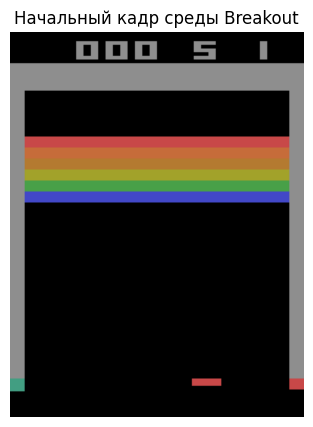

In [3]:
# Создание среды Atari Breakout и вывод основных характеристик

env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")

print("Среда:", "ALE/Breakout-v5")
print("Пространство наблюдений:")
print(env.observation_space)

print("\nПространство действий:")
print(env.action_space)

print("\nКоличество действий:", env.action_space.n)

state, info = env.reset()
print("\nРазмер исходного кадра:", state.shape)

action_meanings = env.unwrapped.get_action_meanings()
print("\nСписок действий:")
for i, action_name in enumerate(action_meanings):
    print(i, "-", action_name)

plt.figure(figsize=(5, 5))
plt.imshow(state)
plt.axis("off")
plt.title("Начальный кадр среды Breakout")
plt.show()

Размер обработанного состояния: (4, 84, 84)
Тип данных: <class 'numpy.ndarray'>
Минимальное значение: 0.0
Максимальное значение: 0.5803922


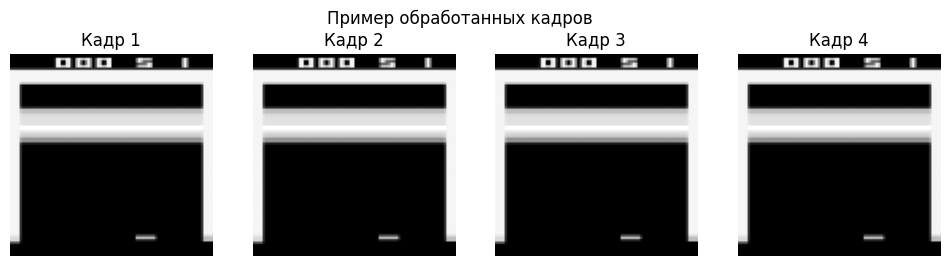

In [4]:
# Предобработка кадров среды Atari Breakout

processed_env = gym.make(
    "ALE/Breakout-v5",
    render_mode="rgb_array",
    frameskip=1
)

processed_env = AtariPreprocessing(
    processed_env,
    frame_skip=4,
    grayscale_obs=True,
    scale_obs=True,
    screen_size=84
)

processed_env = FrameStackObservation(processed_env, stack_size=4)

state, info = processed_env.reset()

print("Размер обработанного состояния:", state.shape)
print("Тип данных:", type(state))
print("Минимальное значение:", np.min(state))
print("Максимальное значение:", np.max(state))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(np.array(state[i]), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Кадр {i+1}")

plt.suptitle("Пример обработанных кадров")
plt.show()

In [5]:
# Создание буфера воспроизведения опыта Replay Buffer

class ReplayBuffer:
    '''
    Буфер воспроизведения опыта для хранения переходов агента.
    '''

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)


    def push(self, state, action, reward, next_state, done):
        '''
        Добавление одного перехода в буфер.
        '''
        self.buffer.append((state, action, reward, next_state, done))


    def sample(self, batch_size):
        '''
        Случайная выборка мини-батча из буфера.
        '''
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones


    def __len__(self):
        '''
        Получение текущего размера буфера.
        '''
        return len(self.buffer)


replay_buffer = ReplayBuffer(capacity=10000)

state, info = processed_env.reset()
action = processed_env.action_space.sample()
next_state, reward, terminated, truncated, info = processed_env.step(action)
done = terminated or truncated

replay_buffer.push(state, action, reward, next_state, done)

print("Буфер воспроизведения успешно создан")
print("Максимальный размер буфера:", replay_buffer.buffer.maxlen)
print("Текущий размер буфера:", len(replay_buffer))
print("Размер состояния в буфере:", np.array(state).shape)
print("Пример действия:", action)
print("Пример награды:", reward)
print("Признак завершения эпизода:", done)

Буфер воспроизведения успешно создан
Максимальный размер буфера: 10000
Текущий размер буфера: 1
Размер состояния в буфере: (4, 84, 84)
Пример действия: 0
Пример награды: 0.0
Признак завершения эпизода: False


In [6]:
# Создание сверточной нейронной сети DQN

class DQN(nn.Module):
    '''
    Сверточная нейронная сеть для аппроксимации Q-функции.
    '''

    def __init__(self, input_channels, num_actions):
        super(DQN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions)
        )


    def forward(self, x):
        '''
        Прямой проход сети.
        '''
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        q_values = self.fc_layers(x)
        return q_values


num_actions = processed_env.action_space.n
input_channels = 4

policy_net = DQN(input_channels, num_actions).to(device)
target_net = DQN(input_channels, num_actions).to(device)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

sample_state = torch.tensor(np.array(state), dtype=torch.float32).unsqueeze(0).to(device)
sample_q_values = policy_net(sample_state)

print("Сверточная нейронная сеть DQN успешно создана")
print("Количество входных каналов:", input_channels)
print("Количество действий:", num_actions)
print("Размер входного состояния:", sample_state.shape)
print("Размер выходного тензора Q-значений:", sample_q_values.shape)
print("\nАрхитектура сети:")
print(policy_net)

Сверточная нейронная сеть DQN успешно создана
Количество входных каналов: 4
Количество действий: 4
Размер входного состояния: torch.Size([1, 4, 84, 84])
Размер выходного тензора Q-значений: torch.Size([1, 4])

Архитектура сети:
DQN(
  (conv_layers): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [7]:
# Создание агента DQN

class DQNAgent:
    '''
    Агент DQN для обучения в среде Atari Breakout.
    '''

    def __init__(self, env, policy_net, target_net, replay_buffer,
                 gamma=0.99, lr=0.0001, batch_size=32,
                 epsilon_start=1.0, epsilon_end=0.1, epsilon_decay=5000,
                 target_update=500):

        self.env = env
        self.policy_net = policy_net
        self.target_net = target_net
        self.replay_buffer = replay_buffer

        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.target_update = target_update

        self.num_actions = env.action_space.n
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        self.steps_done = 0
        self.episodes_reward = []
        self.episodes_steps = []
        self.loss_history = []


    def select_action(self, state):
        '''
        Выбор действия на основе epsilon-greedy стратегии.
        '''
        self.steps_done += 1

        self.epsilon = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
            np.exp(-1.0 * self.steps_done / self.epsilon_decay)

        if random.random() < self.epsilon:
            return self.env.action_space.sample()

        state_tensor = torch.tensor(np.array(state), dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)

        return q_values.argmax().item()


    def optimize_model(self):
        '''
        Обновление параметров нейронной сети на основе мини-батча из Replay Buffer.
        '''
        if len(self.replay_buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        current_q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        loss = self.loss_fn(current_q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()

        self.loss_history.append(loss.item())
        return loss.item()


    def print_info(self):
        '''
        Вывод основной информации об агенте.
        '''
        print("Агент DQN успешно создан")
        print("Количество действий:", self.num_actions)
        print("Gamma:", self.gamma)
        print("Batch size:", self.batch_size)
        print("Начальное epsilon:", self.epsilon_start)
        print("Минимальное epsilon:", self.epsilon_end)
        print("Target update:", self.target_update)
        print("Размер Replay Buffer:", self.replay_buffer.buffer.maxlen)


dqn_agent = DQNAgent(
    env=processed_env,
    policy_net=policy_net,
    target_net=target_net,
    replay_buffer=ReplayBuffer(capacity=10000)
)

dqn_agent.print_info()

Агент DQN успешно создан
Количество действий: 4
Gamma: 0.99
Batch size: 32
Начальное epsilon: 1.0
Минимальное epsilon: 0.1
Target update: 500
Размер Replay Buffer: 10000


In [8]:
# Обучение агента DQN в среде Atari Breakout

def train_dqn_agent(agent, num_episodes=30, max_steps=1000):
    '''
    Обучение агента DQN на нескольких эпизодах.
    '''
    start_time = time.time()

    for episode in tqdm(range(num_episodes)):
        state, info = agent.env.reset()

        total_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = agent.env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(state, action, reward, next_state, done)
            loss = agent.optimize_model()

            state = next_state
            total_reward += reward
            steps += 1

            if agent.steps_done % agent.target_update == 0:
                agent.target_net.load_state_dict(agent.policy_net.state_dict())

        agent.episodes_reward.append(total_reward)
        agent.episodes_steps.append(steps)

        print(
            "Эпизод:", episode + 1,
            "| Награда:", total_reward,
            "| Шаги:", steps,
            "| Epsilon:", round(agent.epsilon, 4)
        )

    training_time = time.time() - start_time

    print("\nОбучение DQN завершено")
    print("Количество эпизодов:", num_episodes)
    print("Время обучения:", training_time)
    print("Средняя награда:", np.mean(agent.episodes_reward))
    print("Среднее количество шагов:", np.mean(agent.episodes_steps))
    print("Финальное значение epsilon:", agent.epsilon)
    print("Количество обновлений loss:", len(agent.loss_history))

    return training_time


training_time = train_dqn_agent(dqn_agent, num_episodes=30, max_steps=1000)

  3%|▎         | 1/30 [00:01<00:48,  1.67s/it]

Эпизод: 1 | Награда: 0.0 | Шаги: 145 | Epsilon: 0.9743


  7%|▋         | 2/30 [00:03<00:46,  1.65s/it]

Эпизод: 2 | Награда: 1.0 | Шаги: 175 | Epsilon: 0.9442


 10%|█         | 3/30 [00:05<00:57,  2.12s/it]

...

Эпизод: 28 | Награда: 0.0 | Шаги: 154 | Epsilon: 0.4131


 97%|█████████▋| 29/30 [00:51<00:01,  1.75s/it]

Эпизод: 29 | Награда: 1.0 | Шаги: 186 | Epsilon: 0.4016


100%|██████████| 30/30 [00:52<00:00,  1.75s/it]

Эпизод: 30 | Награда: 0.0 | Шаги: 142 | Epsilon: 0.3932

Обучение DQN завершено
Количество эпизодов: 30
Время обучения: 52.641223669052124
Средняя награда: 1.0666666666666667
Среднее количество шагов: 186.93333333333334
Финальное значение epsilon: 0.3931823479304156
Количество обновлений loss: 5577


In [9]:
# Проверка обученного агента DQN

def evaluate_dqn_agent(agent, episodes_count=5, max_steps=1000):
    '''
    Проверка качества обученного агента DQN.
    '''
    test_rewards = []
    test_steps = []

    old_epsilon = agent.epsilon

    for episode in range(episodes_count):
        state, info = agent.env.reset()

        total_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            state_tensor = torch.tensor(np.array(state), dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                q_values = agent.policy_net(state_tensor)
                action = q_values.argmax().item()

            next_state, reward, terminated, truncated, info = agent.env.step(action)
            done = terminated or truncated

            state = next_state
            total_reward += reward
            steps += 1

        test_rewards.append(total_reward)
        test_steps.append(steps)

        print(
            "Тестовый эпизод:", episode + 1,
            "| Награда:", total_reward,
            "| Шаги:", steps
        )

    agent.epsilon = old_epsilon

    print("\nПроверка обученного агента DQN завершена")
    print("Количество тестовых эпизодов:", episodes_count)
    print("Средняя тестовая награда:", np.mean(test_rewards))
    print("Среднее количество шагов:", np.mean(test_steps))
    print("Минимальная награда:", np.min(test_rewards))
    print("Максимальная награда:", np.max(test_rewards))

    return test_rewards, test_steps


test_rewards, test_steps = evaluate_dqn_agent(dqn_agent, episodes_count=5, max_steps=1000)

Тестовый эпизод: 1 | Награда: 0.0 | Шаги: 575
Тестовый эпизод: 2 | Награда: 0.0 | Шаги: 153
Тестовый эпизод: 3 | Награда: 1.0 | Шаги: 962
Тестовый эпизод: 4 | Награда: 0.0 | Шаги: 152
Тестовый эпизод: 5 | Награда: 1.0 | Шаги: 1000

Проверка обученного агента DQN завершена
Количество тестовых эпизодов: 5
Средняя тестовая награда: 0.4
Среднее количество шагов: 568.4
Минимальная награда: 0.0
Максимальная награда: 1.0


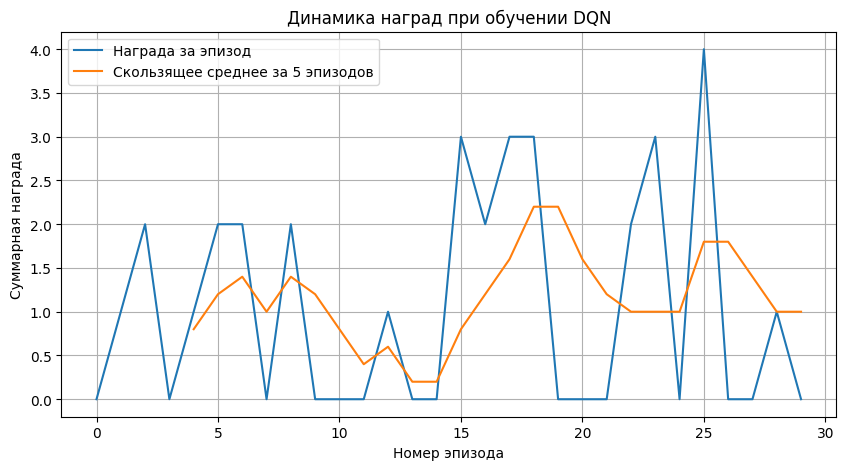

In [10]:
# Построение графика наград при обучении DQN

plt.figure(figsize=(10, 5))

plt.plot(dqn_agent.episodes_reward, label="Награда за эпизод")

if len(dqn_agent.episodes_reward) >= 5:
    moving_average = pd.Series(dqn_agent.episodes_reward).rolling(5).mean()
    plt.plot(moving_average, label="Скользящее среднее за 5 эпизодов")

plt.title("Динамика наград при обучении DQN")
plt.xlabel("Номер эпизода")
plt.ylabel("Суммарная награда")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Формирование итоговой таблицы результатов лабораторной работы

final_results = pd.DataFrame({
    "Показатель": [
        "Среда",
        "Архитектура нейронной сети",
        "Размер обработанного состояния",
        "Количество действий",
        "Количество эпизодов обучения",
        "Время обучения",
        "Средняя награда при обучении",
        "Среднее количество шагов при обучении",
        "Количество тестовых эпизодов",
        "Средняя тестовая награда",
        "Среднее количество шагов при тестировании",
        "Минимальная тестовая награда",
        "Максимальная тестовая награда"
    ],
    "Значение": [
        "ALE/Breakout-v5",
        "Сверточная нейронная сеть",
        "(4, 84, 84)",
        processed_env.action_space.n,
        len(dqn_agent.episodes_reward),
        training_time,
        np.mean(dqn_agent.episodes_reward),
        np.mean(dqn_agent.episodes_steps),
        len(test_rewards),
        np.mean(test_rewards),
        np.mean(test_steps),
        np.min(test_rewards),
        np.max(test_rewards)
    ]
})

final_results

,Показатель,Значение
0,Среда,ALE/Breakout-v5
1,Архитектура нейронной сети,Сверточная нейронная сеть
2,Размер обработанного состояния,"(4, 84, 84)"
3,Количество действий,4
4,Количество эпизодов обучения,30
5,Время обучения,52.641224
6,Средняя награда при обучении,1.066667
7,Среднее количество шагов при обучении,186.933333
8,Количество тестовых эпизодов,5
9,Средняя тестовая награда,0.4
